### EDA

In [64]:
import pandas as pd

In [ ]:
#read data
df = pd.read_csv('health.csv')
print(df.shape)
df.head()

(374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
# some cleaning and processing to
df = df.drop(['Person ID', 'Blood Pressure'], axis=1) #dropping due to difficultiny in processing
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder")
df = pd.get_dummies(df, drop_first=False, columns=["Sleep Disorder", "Gender", 'Occupation', 'BMI Category'],
                    prefix=["SD", "G", 'Occ', 'BMI'])
df = df.astype(int)

In [67]:
df.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,SD_Insomnia,SD_No Disorder,SD_Sleep Apnea,...,Occ_Nurse,Occ_Sales Representative,Occ_Salesperson,Occ_Scientist,Occ_Software Engineer,Occ_Teacher,BMI_Normal,BMI_Normal Weight,BMI_Obese,BMI_Overweight
0,27,6,6,42,6,77,4200,0,1,0,...,0,0,0,0,1,0,0,0,0,1
1,28,6,6,60,8,75,10000,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2,28,6,6,60,8,75,10000,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,28,5,4,30,8,85,3000,0,0,1,...,0,1,0,0,0,0,0,0,1,0
4,28,5,4,30,8,85,3000,0,0,1,...,0,1,0,0,0,0,0,0,1,0


In [68]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,SD_Insomnia,SD_No Disorder,SD_Sleep Apnea,...,Occ_Nurse,Occ_Sales Representative,Occ_Salesperson,Occ_Scientist,Occ_Software Engineer,Occ_Teacher,BMI_Normal,BMI_Normal Weight,BMI_Obese,BMI_Overweight
Age,1.000000,0.436642,0.473734,0.178993,-0.422344,-0.225606,0.057973,0.078478,-0.432007,0.445719,...,0.546397,-0.120078,0.047562,-0.104251,-0.131260,-0.018359,-0.446153,-0.107106,-0.080075,0.532606
Sleep Duration,0.436642,1.000000,0.928789,0.199437,-0.812763,-0.513921,-0.011985,-0.432852,0.314666,0.049251,...,0.109953,-0.167310,-0.301254,-0.169826,-0.068687,-0.273498,0.318810,0.045996,-0.055754,-0.328941
Quality of Sleep,0.473734,0.928789,1.000000,0.192896,-0.898752,-0.659865,0.016791,-0.332406,0.310984,-0.046254,...,0.023495,-0.203211,-0.335950,-0.201176,-0.070702,-0.097806,0.304475,0.023616,-0.126574,-0.280398
Physical Activity Level,0.178993,0.199437,0.192896,1.000000,-0.034134,0.136971,0.772723,-0.302352,-0.069787,0.385533,...,0.459681,-0.102819,-0.208373,-0.090821,-0.055834,-0.225345,-0.074196,0.013626,-0.033234,0.080343
Stress Level,-0.422344,-0.812763,-0.898752,-0.034134,1.000000,0.670026,0.186829,0.139380,-0.181685,0.081582,...,0.045274,0.108196,0.278757,0.094753,0.036081,-0.167945,-0.151259,-0.026776,0.029459,0.157406
Heart Rate,-0.225606,-0.513921,-0.659865,0.136971,0.670026,1.000000,-0.030309,0.037201,-0.330254,0.363420,...,0.218708,0.263356,0.135847,0.209811,0.134287,-0.246407,-0.363291,0.066138,0.567226,0.152863
Daily Steps,0.057973,-0.011985,0.016791,0.772723,0.186829,-0.030309,1.000000,-0.288518,0.026575,0.254924,...,0.378152,-0.173210,-0.154642,-0.094393,-0.065435,-0.184056,0.045434,-0.007575,-0.355639,0.074473
SD_Insomnia,0.078478,-0.432852,-0.332406,-0.302352,0.139380,0.037201,-0.288518,1.000000,-0.605234,-0.261378,...,-0.200700,-0.037335,0.529829,-0.052942,0.011345,0.401501,-0.438782,-0.066742,0.079572,0.453408
SD_No Disorder,-0.432007,0.314666,0.310984,-0.069787,-0.181685,-0.330254,0.026575,-0.605234,1.000000,-0.610180,...,-0.462127,-0.087156,-0.324787,-0.018059,0.034707,-0.253291,0.747698,0.110887,-0.197018,-0.751018
SD_Sleep Apnea,0.445719,0.049251,-0.046254,0.385533,0.081582,0.363420,0.254924,-0.261378,-0.610180,1.000000,...,0.760092,0.142837,-0.133495,0.074587,-0.053374,-0.092468,-0.469915,-0.068030,0.159697,0.459385


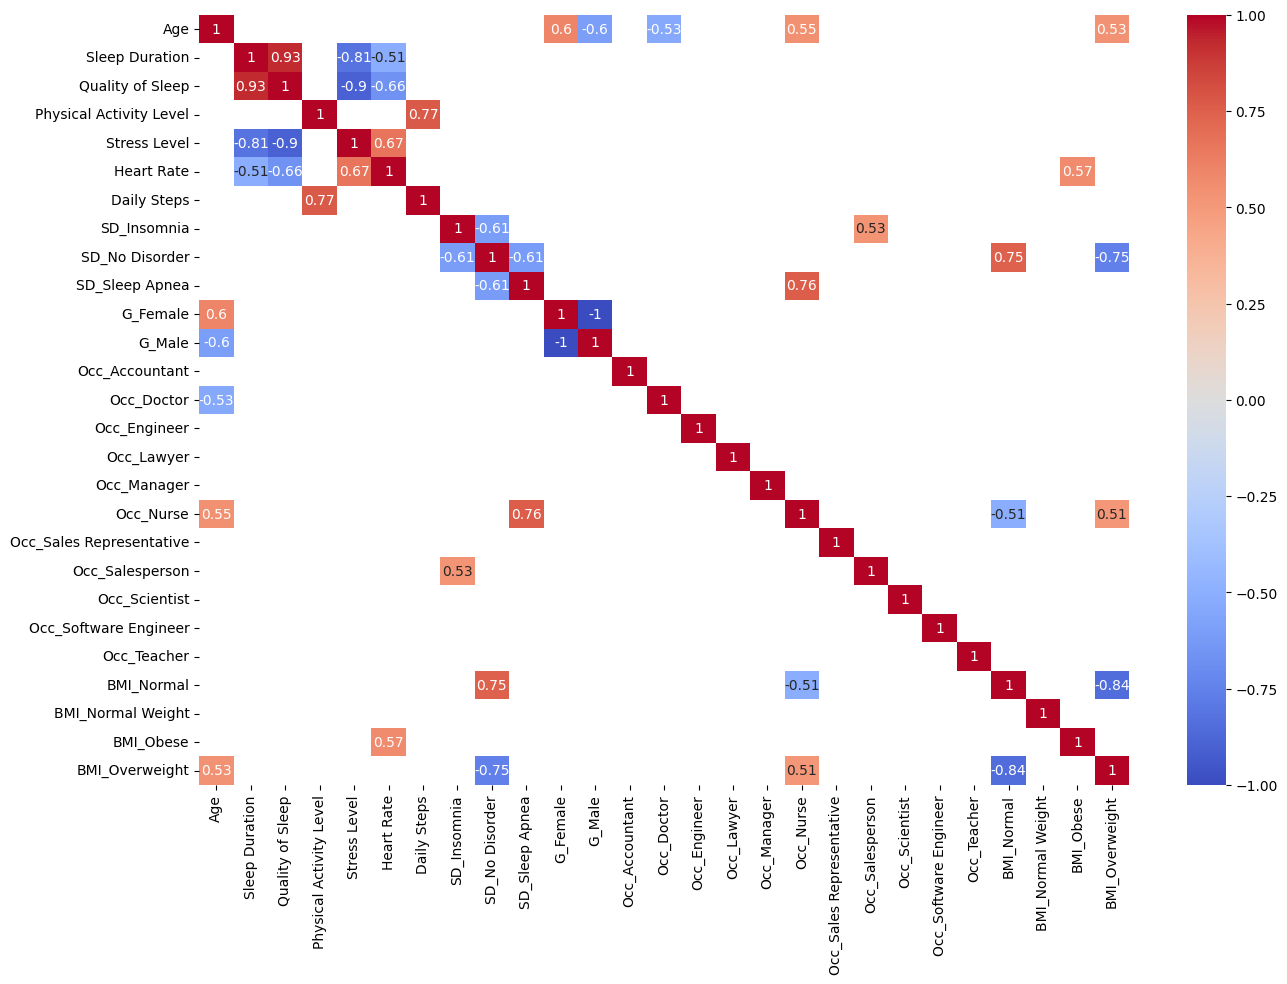

In [ ]:
# visualize high impact correlations
import seaborn as sns
import matplotlib.pyplot as plt

# Set a cutoff
cutoff = 0.5  
mask = corr_matrix.abs() >= cutoff  
plt.figure(figsize=(15, 10))  # width=15, height=10 in inches
sns.heatmap(corr_matrix[mask], annot=True, cmap="coolwarm")
plt.show()

### Modeling

In [70]:
df['Stress Level'].value_counts()

Stress Level
3    71
8    70
4    70
5    67
7    50
6    46
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# create and train a random forest model on the subset of features
X = df[['BMI_Normal Weight', 'BMI_Overweight', 'BMI_Obese', 'Age', 'Daily Steps']]
y = df["Stress Level"]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,    # number of trees
    max_depth=None,     # let trees grow fully
    random_state=42
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# collect predictions and display results
y_pred = rf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           3       1.00      0.93      0.96        14
           4       0.92      0.79      0.85        14
           5       1.00      1.00      1.00        14
           6       0.86      0.67      0.75         9
           7       0.75      0.90      0.82        10
           8       0.82      1.00      0.90        14

    accuracy                           0.89        75
   macro avg       0.89      0.88      0.88        75
weighted avg       0.90      0.89      0.89        75

Confusion Matrix:
 [[13  0  0  1  0  0]
 [ 0 11  0  0  3  0]
 [ 0  0 14  0  0  0]
 [ 0  1  0  6  0  2]
 [ 0  0  0  0  9  1]
 [ 0  0  0  0  0 14]]


### PDP

3


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

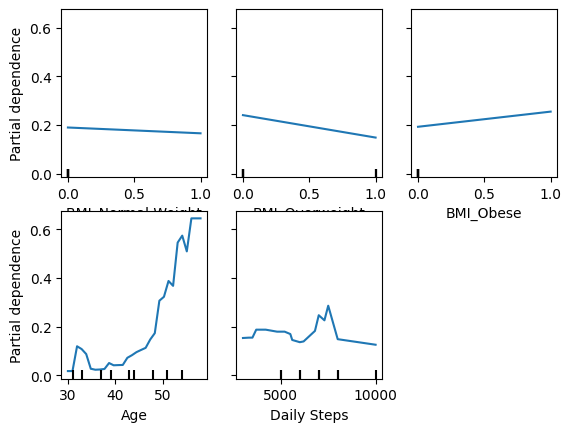

4


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

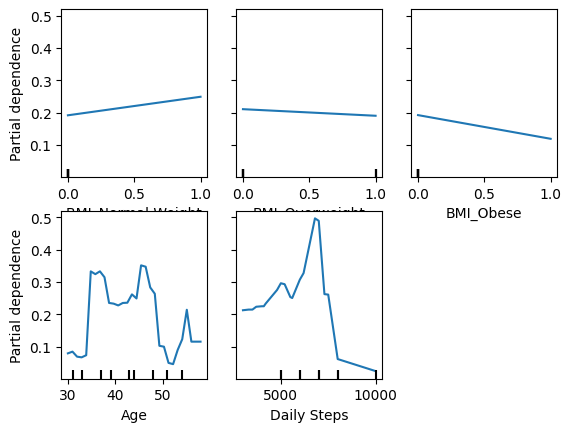

5


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

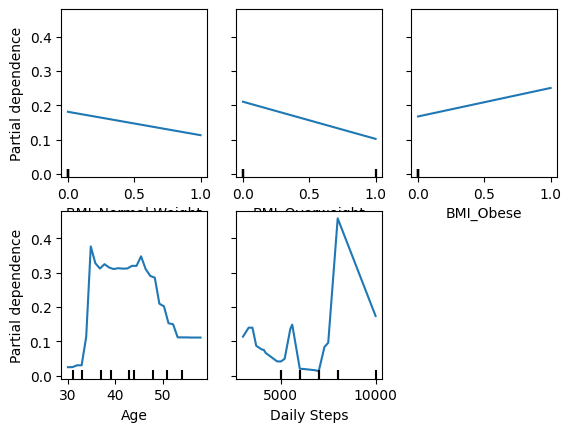

6


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

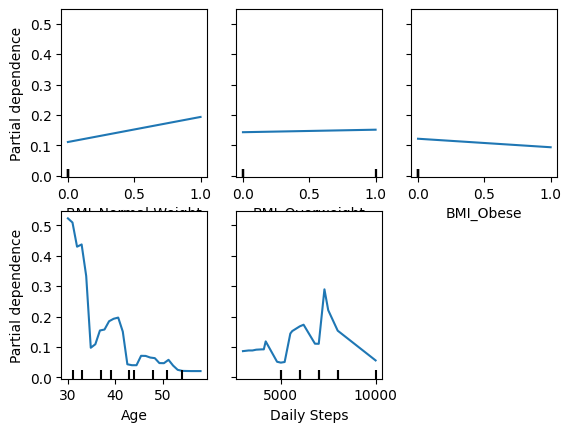

7


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

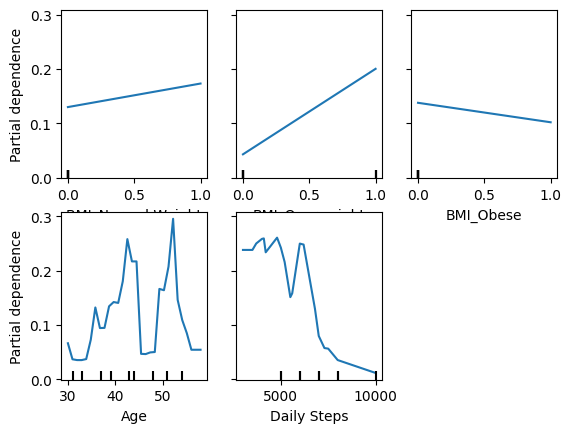

8


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

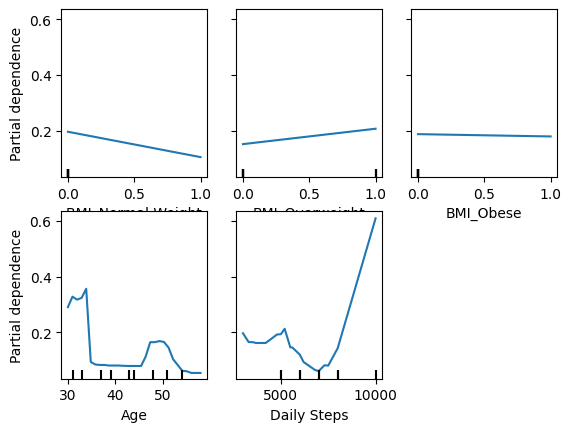

In [ ]:
# iterate over each feature for pdp plots
from sklearn.inspection import PartialDependenceDisplay

for i in range(3,9):
    print(i)
    PartialDependenceDisplay.from_estimator(
        rf, X_train, ['BMI_Normal Weight', 'BMI_Overweight', 'BMI_Obese', 'Age', 'Daily Steps'],
        kind="average", grid_resolution=30, target=i
    )
    plt.show()


### ICE

3


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

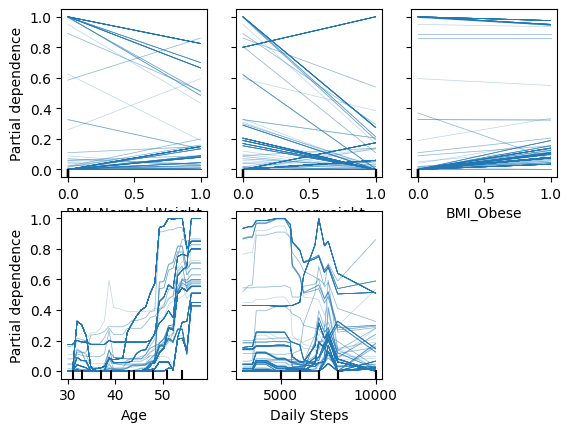

4


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

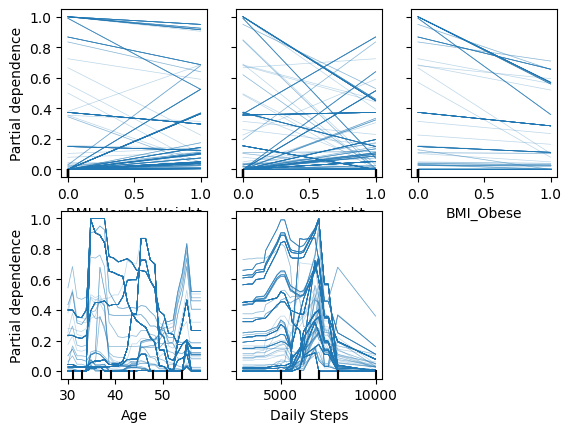

5


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

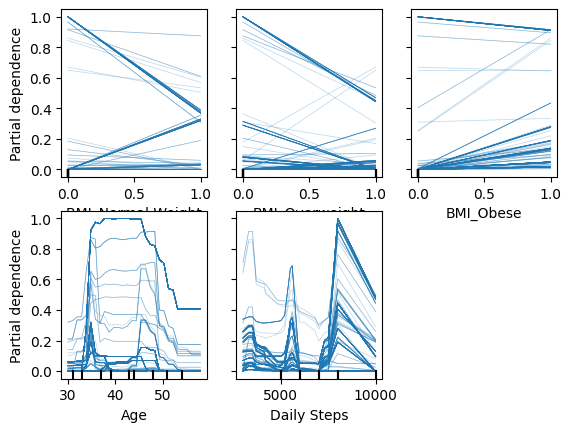

6


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

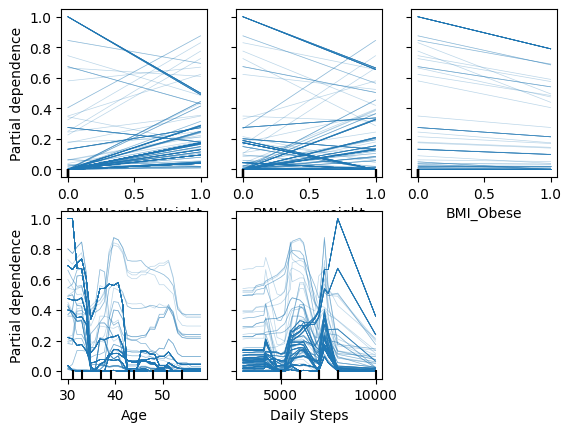

7


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

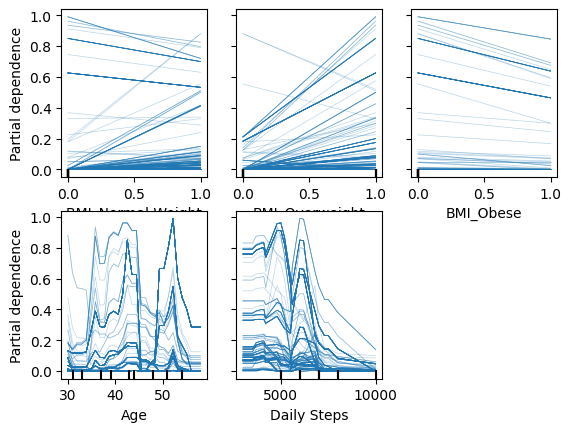

8


c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniques2\exv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\thete\Github\Explainable-Techniqu

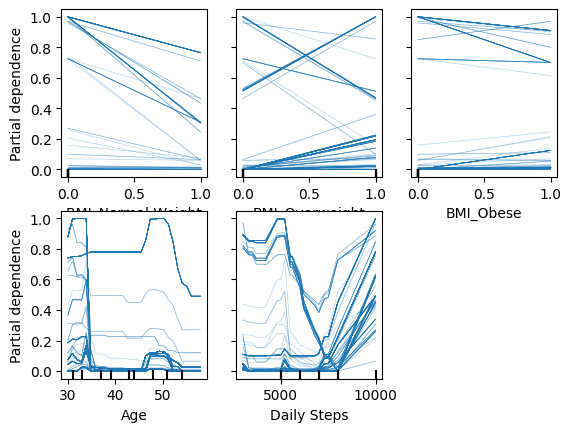

In [ ]:
# iterate over each feature for ice plots

for i in range(3,9):
    print(i)
    PartialDependenceDisplay.from_estimator(
        rf, X_train, ['BMI_Normal Weight', 'BMI_Overweight', 'BMI_Obese', 'Age', 'Daily Steps'],
        kind="individual", grid_resolution=30, target=i
    )
    plt.show()

### ALE

PyALE._ALE_generic:INFO: Discrete feature detected.


PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


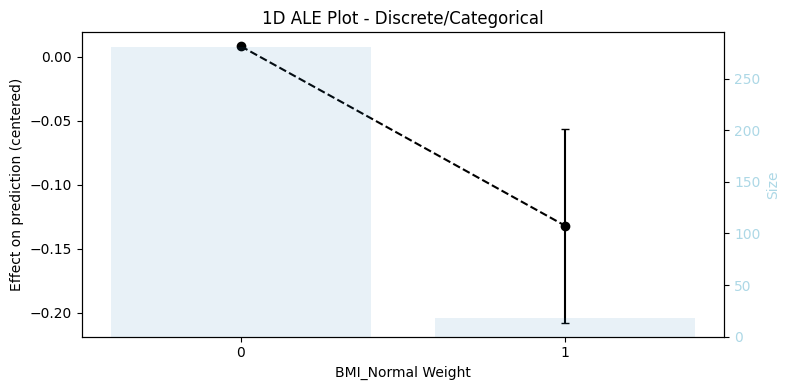

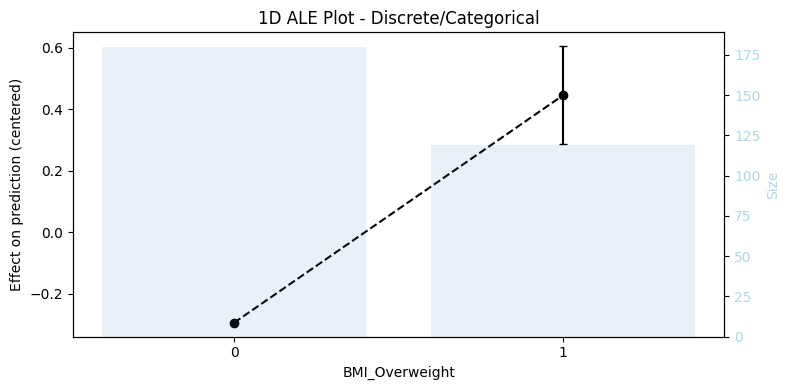

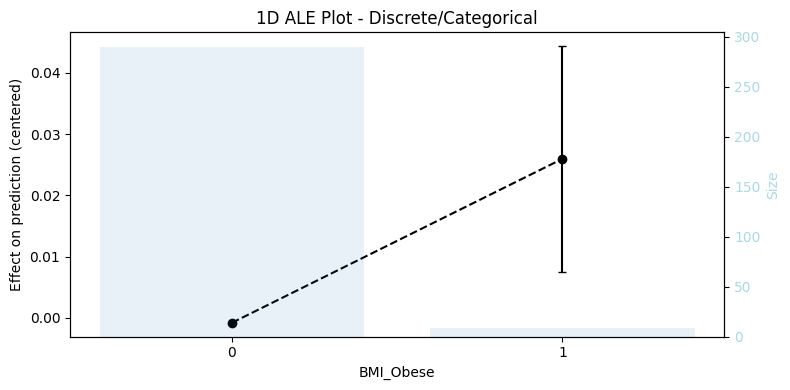

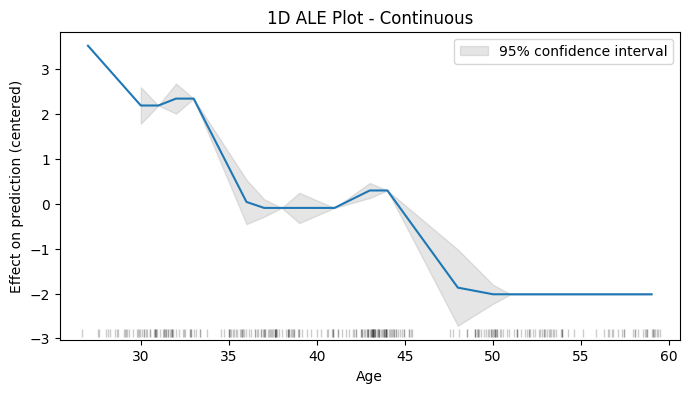

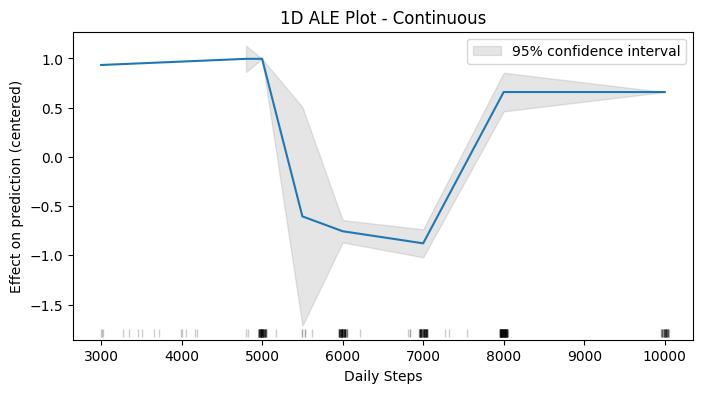

In [ ]:
# ALE plots
from PyALE import ale

features = ['BMI_Normal Weight', 'BMI_Overweight', 'BMI_Obese', 'Age', 'Daily Steps']
for f in features:
    ale(X=X_train, model=rf, feature=[f], grid_size=20)

## Graph Analysis
The PDP plot shows generally little influcne from the categorical obesity values. At times they are neutral or give slight influence. The main changes seem to come from age and steps, each varying between stress level, and at times being non linear meaning certain ranges influence the model in certain ways. <br><br>
In the ICE plot, mainly looking for parallel lines to see heterogeneity in single data instances of a feature. The stress level of 8 has the least, showing that each data point in a feature is holding generally the same influence, but for the other variables it is dependent on the feature. Some categoricals preserve the homogeneity across data points while others are diverse. This ranges throughout the class. <br><br>
The ALE plots show some features to be unimpactful, like not being obese, but show others to bear influence. The continuous variables specifically have interesting impact with the middle range of data influencing little but the extremes bearing much more. <br><br>
The PDP and ALE plots generally follow the same trends, but when broken down by feature, the PDP plot shows much more variability than the ALE plot.
